<a href="https://colab.research.google.com/github/Meqqqiii/ML/blob/main/Costum_Dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
from torch import nn
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import requests
import zipfile
from pathlib import Path
import os
import random
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from timeit import default_timer as timer
import torchinfo
from torchinfo import summary

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

We are going to create a model and train it on Food101 dataset's subset dataset - 3 total classes, 75 training and 25 testing on each

In [ ]:
data_path = Path("data/")
image_path = data_path / "pizza_steak_sushi"

if image_path.is_dir():
  print(f"{image_path} already exists")
else:
  print(f" {image_path} does not exist - creating one ")
  image_path.mkdir(parents= True, exist_ok = True)

data/pizza_steak_sushi already exists


In [ ]:
with open(data_path / "pizza_steak_sushi.zip", "wb") as f:
  request = requests.get("https://github.com/mrdbourke/pytorch-deep-learning/raw/refs/heads/main/data/pizza_steak_sushi.zip")
  print(f"Downloading")
  f.write(request.content)


Downloading


In [ ]:
data_path

PosixPath('data')

In [ ]:
#Downloaded zipfile
with zipfile.ZipFile("/content/data/pizza_steak_sushi.zip", "r")as zip_ref:
  print(f"Unzipping pizza_steak_sushi")
  zip_ref.extractall(image_path)


Unzipping pizza_steak_sushi


So we downloaded data, which consists of 3 classes and 75 training and 25 testing jpg files for each class. Now we somehow should convert them into tensors and build a model to train.

In [ ]:
def walk_through_dir(dir_path):
  for dirpath, dirnames, filenames in os.walk(dir_path):
    print(f"There are {len(dirnames)} directories and {len(filenames)} images in {dirpath}")


In [ ]:
walk_through_dir(image_path)

There are 2 directories and 0 images in data/pizza_steak_sushi
There are 3 directories and 0 images in data/pizza_steak_sushi/train
There are 0 directories and 78 images in data/pizza_steak_sushi/train/pizza
There are 0 directories and 72 images in data/pizza_steak_sushi/train/sushi
There are 0 directories and 75 images in data/pizza_steak_sushi/train/steak
There are 3 directories and 0 images in data/pizza_steak_sushi/test
There are 0 directories and 25 images in data/pizza_steak_sushi/test/pizza
There are 0 directories and 31 images in data/pizza_steak_sushi/test/sushi
There are 0 directories and 19 images in data/pizza_steak_sushi/test/steak


In [ ]:
train_dir = image_path / "train"
test_dir = image_path / "test"

In [ ]:
random.seed(42)

image_path_list = list(image_path.glob("*/*/*.jpg"))

image_path_list #paths of every image

[PosixPath('data/pizza_steak_sushi/train/pizza/2821048.jpg'),
 PosixPath('data/pizza_steak_sushi/train/pizza/2785084.jpg'),
 PosixPath('data/pizza_steak_sushi/train/pizza/300869.jpg'),
 PosixPath('data/pizza_steak_sushi/train/pizza/2811032.jpg'),
 PosixPath('data/pizza_steak_sushi/train/pizza/138855.jpg'),
 PosixPath('data/pizza_steak_sushi/train/pizza/2493954.jpg'),
 PosixPath('data/pizza_steak_sushi/train/pizza/3109486.jpg'),
 PosixPath('data/pizza_steak_sushi/train/pizza/2426686.jpg'),
 PosixPath('data/pizza_steak_sushi/train/pizza/5764.jpg'),
 PosixPath('data/pizza_steak_sushi/train/pizza/2451169.jpg'),
 PosixPath('data/pizza_steak_sushi/train/pizza/739735.jpg'),
 PosixPath('data/pizza_steak_sushi/train/pizza/764429.jpg'),
 PosixPath('data/pizza_steak_sushi/train/pizza/786995.jpg'),
 PosixPath('data/pizza_steak_sushi/train/pizza/12301.jpg'),
 PosixPath('data/pizza_steak_sushi/train/pizza/1572608.jpg'),
 PosixPath('data/pizza_steak_sushi/train/pizza/3338774.jpg'),
 PosixPath('data/p

data/pizza_steak_sushi/train/pizza/1649276.jpg
pizza
Random image path data/pizza_steak_sushi/train/pizza/1649276.jpg
Image class pizza
Image height 384
image width 512


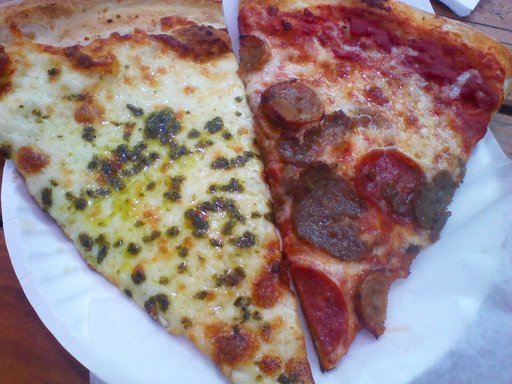

In [ ]:
random.seed(42)
random_image_path = random.choice(image_path_list)
print(random_image_path)
image_class = random_image_path.parent.stem
print(image_class)

img = Image.open(random_image_path)
print(f"Random image path {random_image_path}")
print(f"Image class {image_class}")
print(f"Image height {img.height}")
print(f"image width {img.width}")
img

(-0.5, 511.5, 383.5, -0.5)

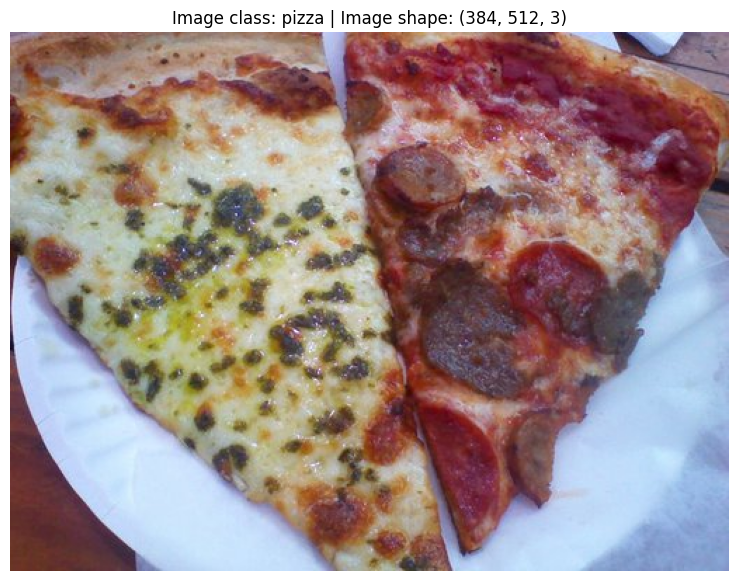

In [ ]:
img_as_array = np.asarray(img)

plt.figure(figsize=(10,7))
plt.imshow(img_as_array)
plt.title(f"Image class: {image_class} | Image shape: {img_as_array.shape}")
plt.axis(False)

# To use our data with pytorch we need to transform it into tensors and for that we will use **torchvision.transforms**

In [ ]:
data_transform = transforms.Compose([
    #Resize to 64-64
    transforms.Resize(size=(64,64)),
    #flip the images
    transforms.RandomHorizontalFlip(p=0.5), #flips image 50% of the time
    #turn image into tensor
    transforms.ToTensor()
])

In [ ]:
data_transform(img).shape # we transformed our data to tensor with shape [C,H,W]

torch.Size([3, 64, 64])

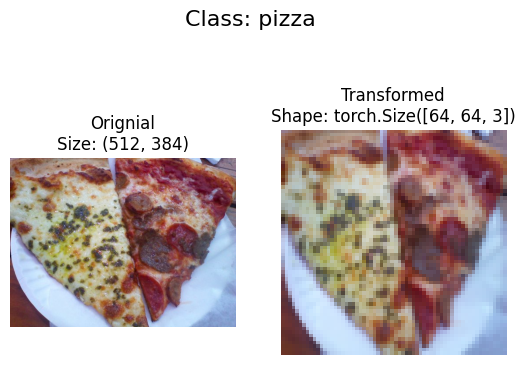

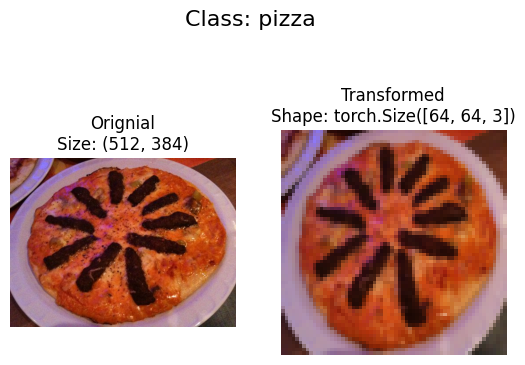

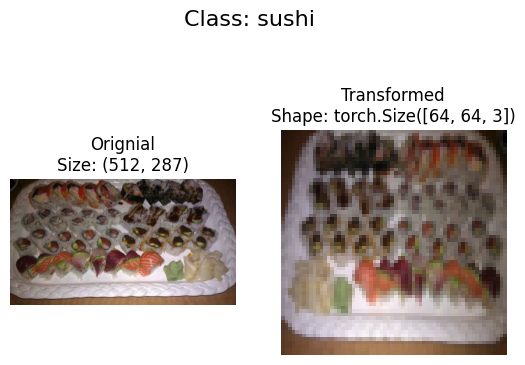

In [ ]:
def plot_transformed_images(image_paths: list, transform, n=3, seed = None):
  if seed:
    random.seed(seed)
  random_image_paths = random.sample(image_paths, k = n)
  for image_path in random_image_paths:
    with Image.open(image_path) as f:
      fig, ax = plt.subplots(nrows = 1, ncols =2)
      ax[0].imshow(f)
      ax[0].set_title(f"Orignial\nSize: {f.size}")
      ax[0].axis(False)

      transformed_image = transform(f).permute(1,2,0) # switching the dimennsinos of the data so that color channels will be at the end because matplot lib requires that shape
      ax[1].imshow(transformed_image)
      ax[1].set_title(f"Transformed\nShape: {transformed_image.shape}")
      ax[1].axis("off")

      fig.suptitle(f"Class: {image_path.parent.stem}", fontsize =16)

plot_transformed_images(image_paths = image_path_list,
                        transform = data_transform,
                        n=3,
                        seed = 42)

In [ ]:
train_data = datasets.ImageFolder(root= train_dir,
                                  transform = data_transform,
                                  target_transform = None)

test_data = datasets.ImageFolder(root = test_dir,
                                 transform = data_transform)
train_data, test_data

(Dataset ImageFolder
     Number of datapoints: 225
     Root location: data/pizza_steak_sushi/train
     StandardTransform
 Transform: Compose(
                Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
                RandomHorizontalFlip(p=0.5)
                ToTensor()
            ),
 Dataset ImageFolder
     Number of datapoints: 75
     Root location: data/pizza_steak_sushi/test
     StandardTransform
 Transform: Compose(
                Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
                RandomHorizontalFlip(p=0.5)
                ToTensor()
            ))

In [ ]:
class_names = train_data.classes
class_dict = train_data.class_to_idx
class_names, class_dict

(['pizza', 'steak', 'sushi'], {'pizza': 0, 'steak': 1, 'sushi': 2})

(-0.5, 63.5, 63.5, -0.5)

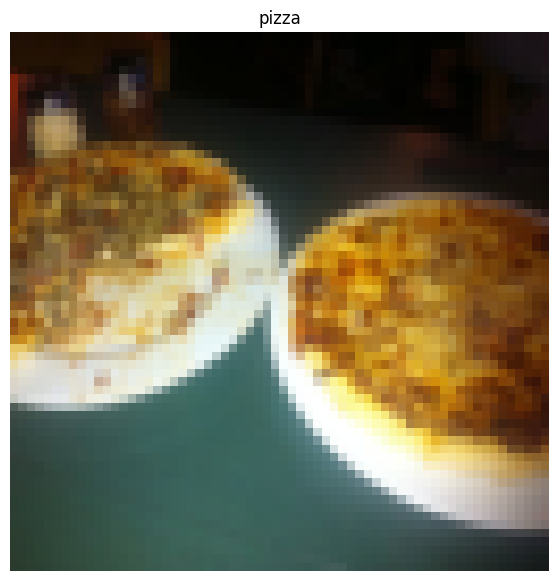

In [ ]:
img,label = train_data[0][0], train_data[0][1]
img = img.permute(1,2,0) # we are chainging shape of the data, converting it to H,W,C
plt.figure(figsize=(10,7))
plt.imshow(img)
plt.title(class_names[label])
plt.axis(False)

# Turning images into DataLoader
Dataloader is going to help us turn data into iterables and we cancustomize the batch_size so our model is more effcient

In [ ]:
BATCH_SIZE = 32
train_dataloader = DataLoader(dataset= train_data,batch_size=BATCH_SIZE,
                              num_workers = os.cpu_count(),
                              shuffle = True)

test_dataloader = DataLoader(dataset=test_data,
                             batch_size = BATCH_SIZE,
                             num_workers= os.cpu_count(),
                             shuffle = False)

img,label = next(iter(train_dataloader))
img.shape,label.shape # 32 images with C H W and 32 labels, one for each

(torch.Size([32, 3, 64, 64]), torch.Size([32]))

# Let's display random images from our dataset

In [ ]:
def display_random_images(dataset:torch.utils.data.Dataset,
                          classes: list[str] = None,
                          n: int = 10,
                          display_shape: bool = True,
                          seed: int = None):
  if n >10:
    n=10
    display_shape = False
    print(f"n Should not be larger than 10 -> setting n to 10")
  if seed:
    random.seed(seed)
  random_samples_idx = random.sample(range(len(dataset)), k =n)

  plt.figure(figsize=(16,8))

  for i, targ_sample in enumerate(random_samples_idx):
    targ_image, targ_label = dataset[targ_sample][0], dataset[targ_sample][1]

    targ_image_adjust = targ_image.permute(1,2,0)

    plt.subplot(1,n, i+1)
    plt.imshow(targ_image_adjust)
    plt.axis("off")
    if classes:
      title = f"CLass: {classes[targ_label]}"
      if display_shape:
        title = title + f"\nshape: {targ_image_adjust.shape}"
    plt.title(title)

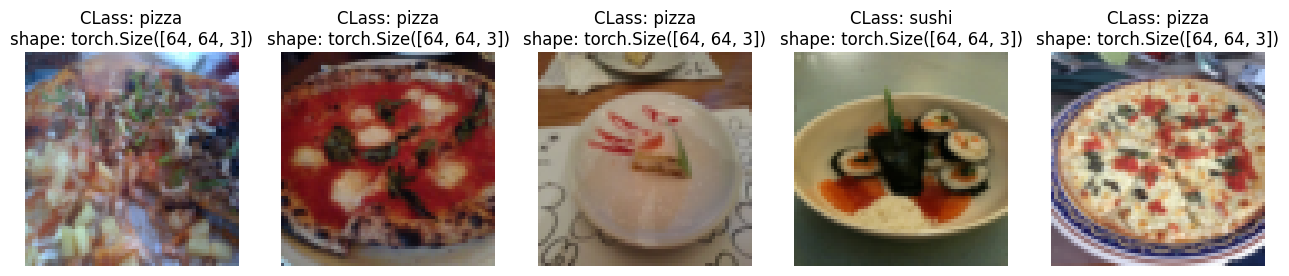

In [ ]:
display_random_images(train_data,n=5,classes = class_names)

## Data agumentation is the process of artificially adding diversity to your training data. In the cases of images it means applying various image transformations to the training images. This practice hopefully results in amodel that's more generalizzable to unseen data.

In [ ]:
train_transform = transforms.Compose([transforms.Resize(size=(224,224)),
                                      transforms.TrivialAugmentWide(num_magnitude_bins = 31),#number zero to 31 descriebs how intense will augmentation happen
                                      transforms.ToTensor()])
test_transform = transforms.Compose([transforms.Resize(size = (224,224)),
                                     transforms.ToTensor()])

In [ ]:
image_path_list = list(image_path.glob("*/*/*.jpg"))
image_path_list[10]

PosixPath('data/pizza_steak_sushi/train/pizza/739735.jpg')

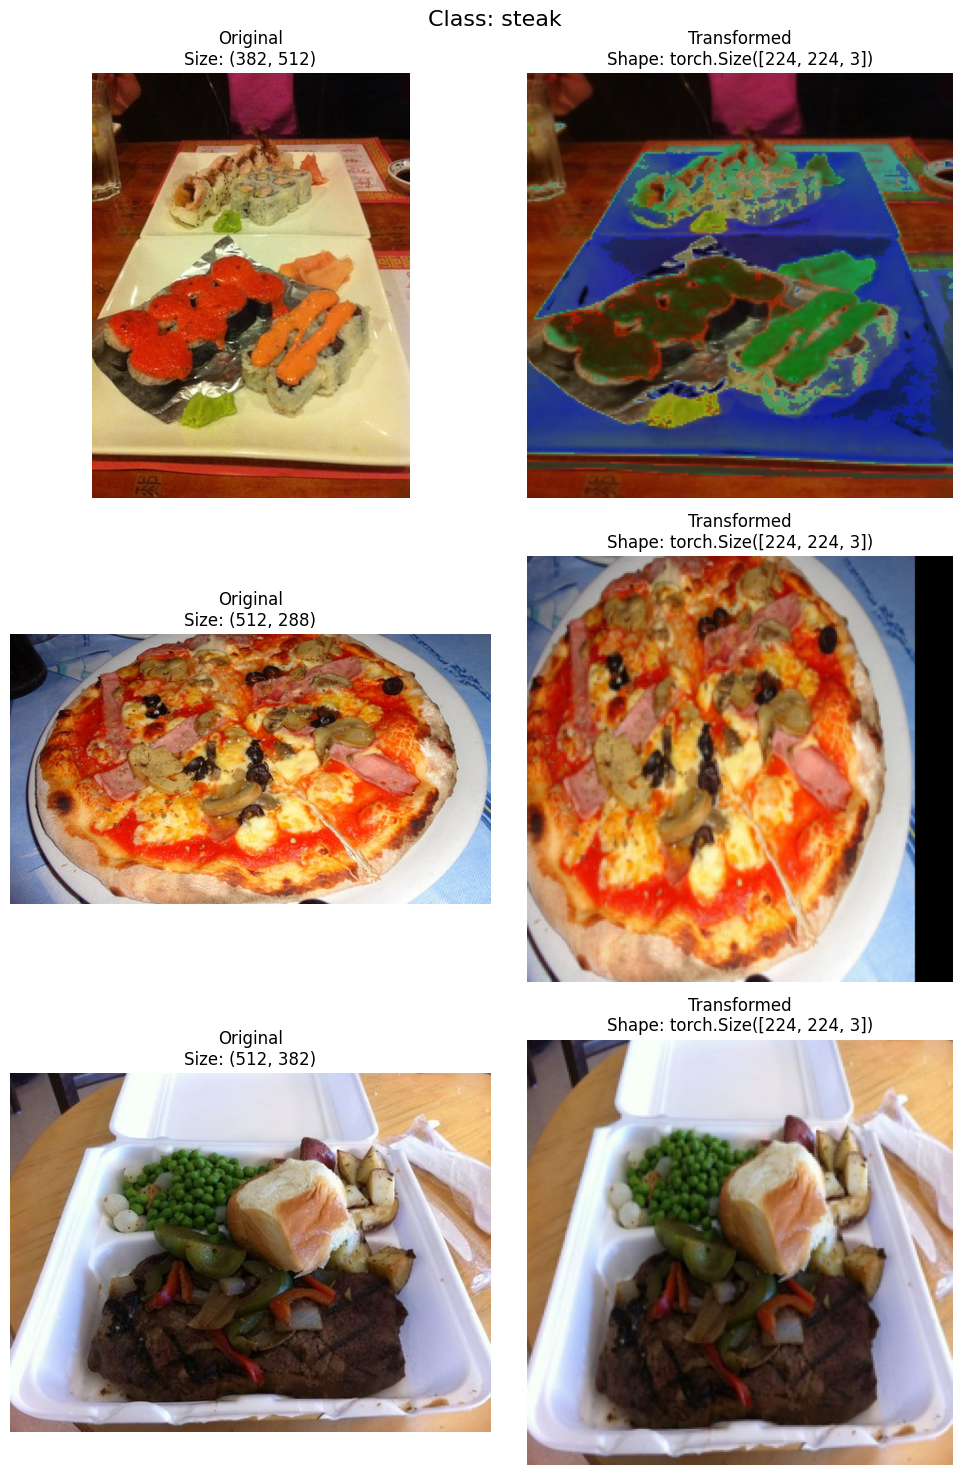

In [ ]:
import random
import matplotlib.pyplot as plt
from PIL import Image

def plot_transformed_images2(image_paths: list, transform, n=3, seed=None):
    if seed is not None:
        random.seed(seed)
    random_image_paths = random.sample(image_paths, k=n)

    fig, axs = plt.subplots(nrows=n, ncols=2, figsize=(10, 5 * n))  # Create subplots for each image
    for i, image_path in enumerate(random_image_paths):
        with Image.open(image_path) as f:
            axs[i, 0].imshow(f)  # Original image
            axs[i, 0].set_title(f"Original\nSize: {f.size}")
            axs[i, 0].axis(False)

            transformed_image = transform(f)  # Apply the transformation
            transformed_image = transformed_image.permute(1, 2, 0)  # Rearrange dimensions for plotting

            # If the transformed image is normalized, you may need to denormalize
            # Uncomment the following lines if needed:
            # transformed_image = transformed_image * 255.0
            # transformed_image = transformed_image.clamp(0, 255).byte()

            axs[i, 1].imshow(transformed_image)  # Transformed image
            axs[i, 1].set_title(f"Transformed\nShape: {transformed_image.shape}")
            axs[i, 1].axis("off")

    fig.suptitle(f"Class: {image_path.parent.stem}", fontsize=16)
    plt.tight_layout()
    plt.show()




plot_transformed_images2(
    image_paths = image_path_list,
    transform = train_transform,
    n=3,
    seed = None
)

# Let's replicate TinyVGG architecture

In [ ]:
simple_transform = transforms.Compose([transforms.Resize(size= (64,64)),
                                      transforms.ToTensor()])
train_data_simple = datasets.ImageFolder(root = train_dir,
                                         transform = simple_transform)
test_data_simple = datasets.ImageFolder(root = test_dir,
                                        transform = simple_transform)

BATCH_SIZE = 32
NUM_WORKERS = os.cpu_count()
train_dataloader_simple = DataLoader(dataset= train_data_simple,
                                     batch_size = BATCH_SIZE,
                                     shuffle = True,
                                     num_workers = NUM_WORKERS)
test_dataloader_simple = DataLoader(dataset= test_data_simple,
                                     batch_size = BATCH_SIZE,
                                     shuffle = True,
                                     num_workers = NUM_WORKERS)

In [ ]:
class TinyVGG(nn.Module):
  def __init__(self,
               input_shape :int,
               hidden_units:int,
               output_shape :int) -> None:
    super().__init__()
    self.conv_block_1 = nn.Sequential(
        nn.Conv2d(in_channels = input_shape,
                  out_channels = hidden_units,
                  kernel_size = 3,
                  stride = 1,
                  padding =0),
        nn.ReLU(),
        nn.Conv2d(
                in_channels = hidden_units,
                out_channels = hidden_units,
                kernel_size = 3,
                stride = 1,
                padding = 0),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2,
                     stride = 2)
        )
    self.conv_block_2 = nn.Sequential(
        nn.Conv2d(in_channels= hidden_units,
                  out_channels = hidden_units,
                  kernel_size = 3,
                  stride = 1,
                  padding =0),
        nn.ReLU(),
        nn.Conv2d(
                in_channels = hidden_units,
                out_channels = hidden_units,
                kernel_size = 3,
                stride = 1,
                padding = 0),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2,
                     stride = 2)
        )
    self.conv_block_3 = nn.Sequential(
        nn.Conv2d(in_channels= hidden_units,
                  out_channels = hidden_units,
                  kernel_size = 3,
                  stride = 1,
                  padding =0),
        nn.ReLU(),
        nn.Conv2d(
                in_channels = hidden_units,
                out_channels = hidden_units,
                kernel_size = 3,
                stride = 1,
                padding = 0),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size=2,
                     stride = 2)
        )
    self.classifier = nn.Sequential(
        nn.Flatten(),
        nn.Linear(in_features =hidden_units * 4 *4,
                  out_features = output_shape)
    )
  def forward(self,x):
    x = self.conv_block_1(x)
    #print(x.shape)
    x = self.conv_block_2(x)
    #print(x.shape)
    x = self.conv_block_3(x)
    x = self.classifier(x)
    #print(x.shape)

    return x
    # return self.classifier(self.conv_block_2(self.conv_block_2(x))) more efficient
    # even though code above is more efficeint we first need to find out what will be an output shape of our tensor


In [ ]:
torch.manual_seed(42)
model_0 = TinyVGG(input_shape=3,
                  hidden_units = 64,
                  output_shape = len(class_names)).to(device)
model_0

TinyVGG(
  (conv_block_1): Sequential(
    (0): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block_2): Sequential(
    (0): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block_3): Sequential(
    (0): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=1024, out_features=3, bias=True)
  )
)

In [ ]:
image_batch, label_batch= next(iter(train_dataloader_simple))
print(image_batch.shape, label_batch.shape)
image_batch, label_batch = image_batch.to(device), label_batch.to(device)
model_0(image_batch)

torch.Size([32, 3, 64, 64]) torch.Size([32])


tensor([[-0.0265,  0.0028, -0.0034],
        [-0.0257,  0.0023, -0.0028],
        [-0.0260,  0.0027, -0.0026],
        [-0.0261,  0.0029, -0.0029],
        [-0.0270,  0.0028, -0.0026],
        [-0.0262,  0.0031, -0.0031],
        [-0.0268,  0.0035, -0.0028],
        [-0.0261,  0.0026, -0.0032],
        [-0.0263,  0.0029, -0.0037],
        [-0.0263,  0.0023, -0.0022],
        [-0.0258,  0.0023, -0.0023],
        [-0.0260,  0.0026, -0.0030],
        [-0.0266,  0.0020, -0.0030],
        [-0.0265,  0.0020, -0.0033],
        [-0.0250,  0.0022, -0.0032],
        [-0.0262,  0.0030, -0.0034],
        [-0.0261,  0.0028, -0.0028],
        [-0.0259,  0.0021, -0.0030],
        [-0.0257,  0.0025, -0.0035],
        [-0.0262,  0.0029, -0.0026],
        [-0.0263,  0.0032, -0.0027],
        [-0.0261,  0.0030, -0.0030],
        [-0.0267,  0.0027, -0.0039],
        [-0.0256,  0.0026, -0.0029],
        [-0.0259,  0.0021, -0.0029],
        [-0.0257,  0.0025, -0.0039],
        [-0.0264,  0.0030, -0.0034],
 

In [ ]:
# installing torchinfo
try:
  import torchinfo
except:
  !pip install torchinfo
  import torchinfo
  from torchinfo import summary
summary(model_0, input_size = [1, 3, 64, 64])

Layer (type:depth-idx)                   Output Shape              Param #
TinyVGG                                  [1, 3]                    --
├─Sequential: 1-1                        [1, 64, 30, 30]           --
│    └─Conv2d: 2-1                       [1, 64, 62, 62]           1,792
│    └─ReLU: 2-2                         [1, 64, 62, 62]           --
│    └─Conv2d: 2-3                       [1, 64, 60, 60]           36,928
│    └─ReLU: 2-4                         [1, 64, 60, 60]           --
│    └─MaxPool2d: 2-5                    [1, 64, 30, 30]           --
├─Sequential: 1-2                        [1, 64, 13, 13]           --
│    └─Conv2d: 2-6                       [1, 64, 28, 28]           36,928
│    └─ReLU: 2-7                         [1, 64, 28, 28]           --
│    └─Conv2d: 2-8                       [1, 64, 26, 26]           36,928
│    └─ReLU: 2-9                         [1, 64, 26, 26]           --
│    └─MaxPool2d: 2-10                   [1, 64, 13, 13]           --


In [ ]:
def train_step(model : torch.nn.Module,
               dataloader : torch.utils.data.DataLoader,
               loss_fn : torch.nn.Module,
               optimizer: torch.optim.Optimizer,
               device = device):
  model.to(device)
  model.train()

  train_loss, train_acc = 0,0

  #loop throuvh dataloader batches
  for batch, (X,y) in enumerate(dataloader):
    #X,y = X.to(device), y.to(device)

    logits = model(X)
    loss = loss_fn(logits, y)
    train_loss += loss.item()

    optimizer.zero_grad()

    loss.backward()

    optimizer.step()

    #Calculate accuracy
    y_preds = torch.argmax(torch.softmax(logits, dim=1 ), dim =1)
    train_acc += (y_preds == y).sum().item()/len(y_preds)
  #getting average per batch
  train_loss = train_loss /len(dataloader)
  train_acc = train_acc / len(dataloader)
  return train_loss, train_acc


In [ ]:
def test_step(model: torch.nn.Module,
              dataloader : torch.utils.data.DataLoader,
              loss_fn : torch.nn.Module,
              device = device):
  model.to(device)
  model.eval()

  test_loss, test_acc = 0,0

  with torch.inference_mode():
    for batch,(X,y) in enumerate(dataloader):
      X,y = X.to(device), y.to(device)

      logits = model(X)
      test_loss += loss_fn(logits,y).item()

      y_preds = torch.argmax(torch.softmax(logits,dim=1), dim =1)
      test_acc += (y_preds == y).sum().item()/len(y_preds)
    test_loss = test_loss / len(dataloader)
    test_acc = test_acc / len(dataloader)
    #print(f"Test loss {test_loss}, Test acc {test_acc}")
    return test_loss, test_acc

In [ ]:
def train(model : torch.nn.Module,
          #rain_step,
          #test_step,
          loss_fn : torch.nn.Module,
          optimizer : torch.optim.Optimizer,
          traindata : torch.utils.data.DataLoader,
          testdata : torch.utils.data.DataLoader,
          epochs: int,
          device = device,):
  results = {"train_loss" : [],
             "train_acc" : [],
             "test_loss" : [],
             "test_acc" : []}

  for epoch in tqdm(range(epochs)):
    #print(f"Epoch: {epoch} \n------")
    train_loss, train_acc = train_step(
                              model,
                              traindata,
                              loss_fn,
                              optimizer,
                              device)

    test_loss, test_acc = test_step(model,testdata,loss_fn,device)

    print(f"Epoch: {epoch} | Train loss: {train_loss:.4f} | Train_acc {train_acc:.4f} | Test loss: {test_loss:.4f} | Test acc {test_acc:.4f}")
    results["train_loss"].append(train_loss)
    results["train_acc"].append(train_acc)
    results["test_loss"].append(test_loss)
    results["test_acc"].append(test_acc)

In [ ]:
torch.manual_seed(42)
torch.cuda.manual_seed(42)
NUM_EPOCHS = 5

model_0 = TinyVGG(input_shape=3,
                  hidden_units = 64,
                  output_shape = len(class_names)).to(device)

loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(params = model_0.parameters(), lr =0.001)

start_time = timer()
train(model_0,loss_fn,optimizer,train_dataloader, test_dataloader, NUM_EPOCHS, device)
end_time = timer()
print(f"Total training time: {end_time - start_time:.3f}")

  0%|          | 0/5 [00:00<?, ?it/s]

RuntimeError: Input type (torch.FloatTensor) and weight type (torch.cuda.FloatTensor) should be the same or input should be a MKLDNN tensor and weight is a dense tensor

## To track our model's progress let's try to plot it's loss curve